## Chain Line extraction for light images transmitted
### Load matlab files
### you can take one of the test files that are in the file called file matlab usefuls

In [ ]:
%pip install numpy scipy matplotlib #this is in case you don’t have the packages installed on your system

In [47]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d, rotate

In [ ]:
u_0 = sio.loadmat('Files_mat_usefuls/filtered_manuscript_5-Cut1.mat') # <----- Enter the relative address of the file to run here from the files folder: files_matlab_usefuls
dec_phi = u_0['f_H'] 
img_ready= np.moveaxis(dec_phi, -1, 0)
num_bands=8

### Fourier Filtering
Enhance chain lines in the frequency domain. First, we define functions for filtering and plotting the filtered images. The rectangularFilter function has the option for vertical and horizontal filtering. The filter_dir should be perpendicular to the chain line direction and depends on the orientation of the image.

In [ ]:
# Define rectangular filter for Fourier filtering 
class rectangleFilter:
    def __init__(self, filter_dir, imgShape):
        self.filter_dir = filter_dir
        self.imgShape = imgShape
    
    def __call__(self, length, width, low_cut=20):
        # filter_dir is based on the orientation of the image. 
        # The filter_dir should be perpendicular to the chain line direction
        base = np.zeros(self.imgShape[:2])
        rows, cols = self.imgShape[:2]
        center_row, center_col = int(rows/2), int(cols/2)
        
        if self.filter_dir == 'vertical': 
            base[length:rows-length, center_col-width:center_col+width] = 1
            # Eliminación del componente DC y las variaciones de iluminación global
            base[center_row-low_cut:center_row+low_cut, center_col-width:center_col+width] = 0
            
        elif self.filter_dir == 'horizontal':
            base[center_row-width:center_row+width, length:cols-length] = 1
            # Eliminación del componente DC y las variaciones de iluminación global
            base[center_row-width:center_row+width, center_col-low_cut:center_col+low_cut] = 0
            
        else:
            print('Error, please select either vertical or horizontal')
        
        return base
    
# Define plotting class
class plot_FFT:
    def __init__(self, Filter, save='False'):
        self.Filter = Filter
        self.save = save
        
    def __call__(self, img, width, length, low_cut=20):
        original = np.fft.fft2(img)
        center = np.fft.fftshift(original) #To replace the low frequency in the center of the fourier domain image (especially the dc component or frequency 0))
        magnitude_spec = np.log(1+np.abs(center)) # Here the frequency spectrum is transformed on a logarithmic scale with low frequencies in the center (usually the second image of the first row ) also within the function in parenting the handling of the complex signal (Fourier transform works with complex frequencies)
        
        fig, axes = plt.subplots(2, 3, figsize=(25,6), constrained_layout=False)
        ax_row = axes[0]
        ax_row[0].imshow(img, "gray")
        ax_row[0].set_title('Spectral TV Image')
        ax_row[0].axis('off')
        ax_row[1].imshow(magnitude_spec, "gray")
        ax_row[1].set_title("Centered Spectrum")
        ax_row[1].axis('off')
        
        # Se aplica el filtro para visualización
        LowPassCenter = center * self.Filter(length, width, low_cut)
        ax_row[2].imshow(np.log(1+np.abs(LowPassCenter)), "gray")
        ax_row[2].set_title("Centered Spectrum multiply Band Pass Filter")
        ax_row[2].axis('off')
        
        ax_row = axes[1]
        
        # Image 1: Width Original, corresponds to the first image of the second row
        LowPass1 = np.fft.ifftshift(center * self.Filter(length, width, low_cut))
        inverse1 = np.fft.ifft2(LowPass1)
        ax_row[0].imshow(np.abs(inverse1), "gray")
        ax_row[0].set_title(f"Processed: length {length}, width {width}")
        ax_row[0].axis('off')
        
        # Image 2: Medium contrast, corresponds to the second image of the second row
        width_2 = max(1, width - 1) 
        LowPass2 = np.fft.ifftshift(center * self.Filter(length, width_2, low_cut))
        inverse2 = np.fft.ifft2(LowPass2)
        ax_row[1].imshow(np.abs(inverse2), "gray")
        ax_row[1].set_title(f"Processed: length {length}, width {width_2}")
        ax_row[1].axis('off')
        
        # Image 3: High contrast, corresponds to the third image of the second row
        width_3 = max(1, width - 2)
        LowPass3 = np.fft.ifftshift(center * self.Filter(length, width_3, low_cut))
        inverse3 = np.fft.ifft2(LowPass3)
        ax_row[2].imshow(np.abs(inverse3), "gray")
        ax_row[2].set_title(f"Processed: length {length}, width {width_3}")
        ax_row[2].axis('off')
        
        if self.save == 'True':
            plt.savefig('FILE_NAME.png')
        plt.show()



Next, we initialise the filter and plotting functions for the decomposed image. In some cases it may be necessary to rotate the image as well for ease of analysis. We choose length and width for the filtering based on the image size. The plotter will render results for width, width-1 and width-2.

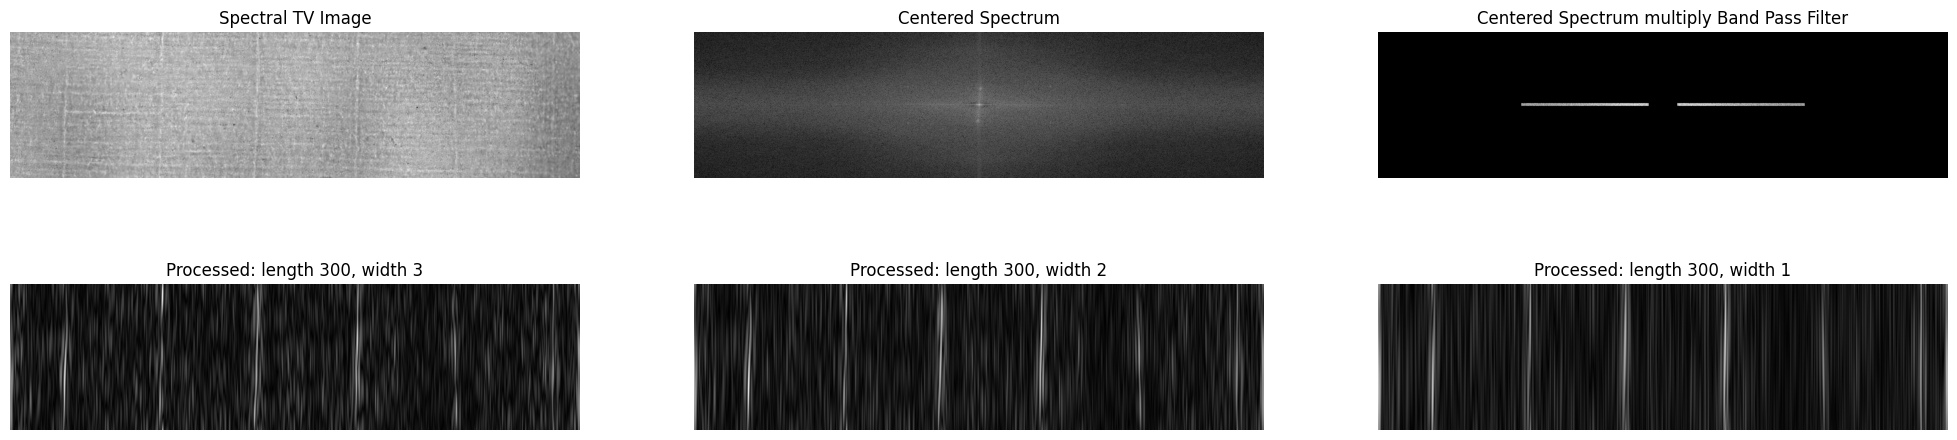

In [ ]:
# --- execution---


img_ready = dec_phi # rotate(dec_phi,90) 
#If the orientation of the image is horizontal, the rotation is necessary to be applied; 
#for this purpose, the code line must be commented on: dec_phi, decommenting the code line next to it: rotate(dec_phi, 90)

if len(img_ready.shape) == 3:
    img_ready = np.mean(img_ready, axis=2)

Filter = rectangleFilter(filter_dir = 'horizontal',imgShape = img_ready.shape)
plotter = plot_FFT(Filter,save='False') # initialise plotter

length = 300 # 
width = 3 #  here the band processing is set, in this case with a maximum of 3 pixels wide
low_cut_value = 30 # This value is adjusted. The value 30 corresponds to the DC component for the removal of white spots belonging to the overall brightness of the image that generate noise when detecting the chain lines
plotter(img_ready,width,length,low_cut_value)

Based on the filtering results, we choose the width that render the best filtered results to use in the rest of the analysis

In [ ]:
# --- VISUAL DECISION ---
# Based on the 3 graphs from the previous step, the number is written below 
# that gave the best result by isolating the chain lines, in most cases will be the value 1
best_width = 1 

# 1.Fourier transform application
original = np.fft.fft2(img_ready) 
center = np.fft.fftshift(original)

# 2. The final filter is applied using the exact choice
LowPassCenter = np.fft.ifftshift(center * Filter(length, best_width)) 

# 3. Reverse transformation and absolute value extraction (actual pixels)
inverse_LowPass = np.abs(np.fft.ifft2(LowPassCenter))

print(f"Permanent filter applied with a thickness of: {best_width}")

Permanent filter applied with a thickness of: 1


### Verticale Projection
Project the filtered image onto the relevant axis.

In [54]:
y = np.sum(np.abs(inverse_LowPass),axis=0) # change to axis=1 for vertical filter
x = np.linspace(0,y.shape[0],y.shape[0])

### Peak detection
Locate peaks with highest magnitude, representing the chain lines. The variable "height" represents the cut-off threshold and is to be chosen manually. We include gaussian smoothing of the 1D signal to filter out noise.

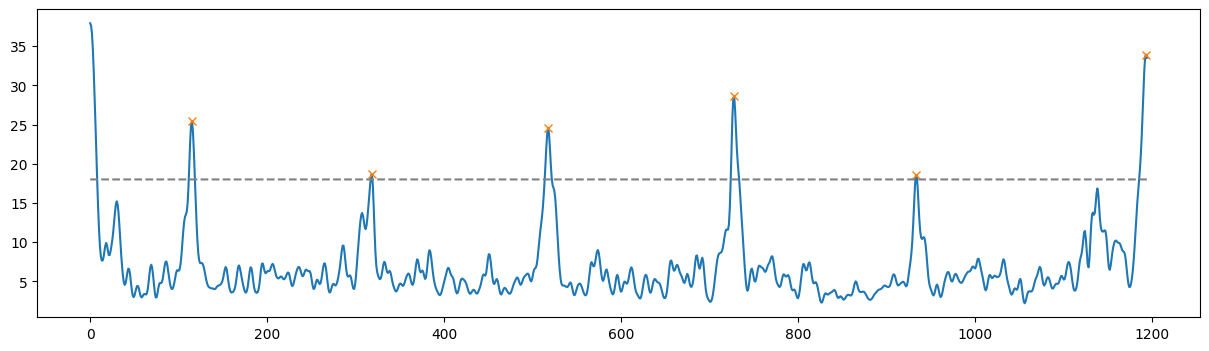

In [ ]:
pixel_size_mm= 0.04065 #this value can change taking into account an algorithm to detect how many pixels there are in 1 millimeter
height=18 #here the threshold from which peaks are to be taken into account to detect chain lines is applied, it can be adjusted but in most cases the value is between 15 and 20
fil=1
sigma = 2 # standard deviation of the gaussian kernel for filtering
if fil ==1:
    y_ = gaussian_filter1d(y,sigma) # smoothing of the signal
else:
    y_ = y
    
peaks_y, _ = find_peaks(y_, height=height)

# Plot the detected peaks in the signal
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
ax.plot(x,y_)
ax.plot(x[peaks_y],y_[peaks_y], "x")
ax.plot(x,height*np.ones_like(x), "--", color="gray")
plt.show()


### Chain line distance measuring and plotting

In [60]:
# np.diff, que hace exactamente (peaks_y[1:] - peaks_y[:-1])
distances_px = np.diff(peaks_y)
distances_mm = distances_px * pixel_size_mm

print(f'The chainline distances in millimeters are: {np.round(distances_mm, 2)}')
print(f'Mean distance: {np.mean(distances_mm):.2f} mm')

The chainline distances in millimeters are: [ 8.25  8.09  8.54  8.33 10.57]
Mean distance: 8.76 mm


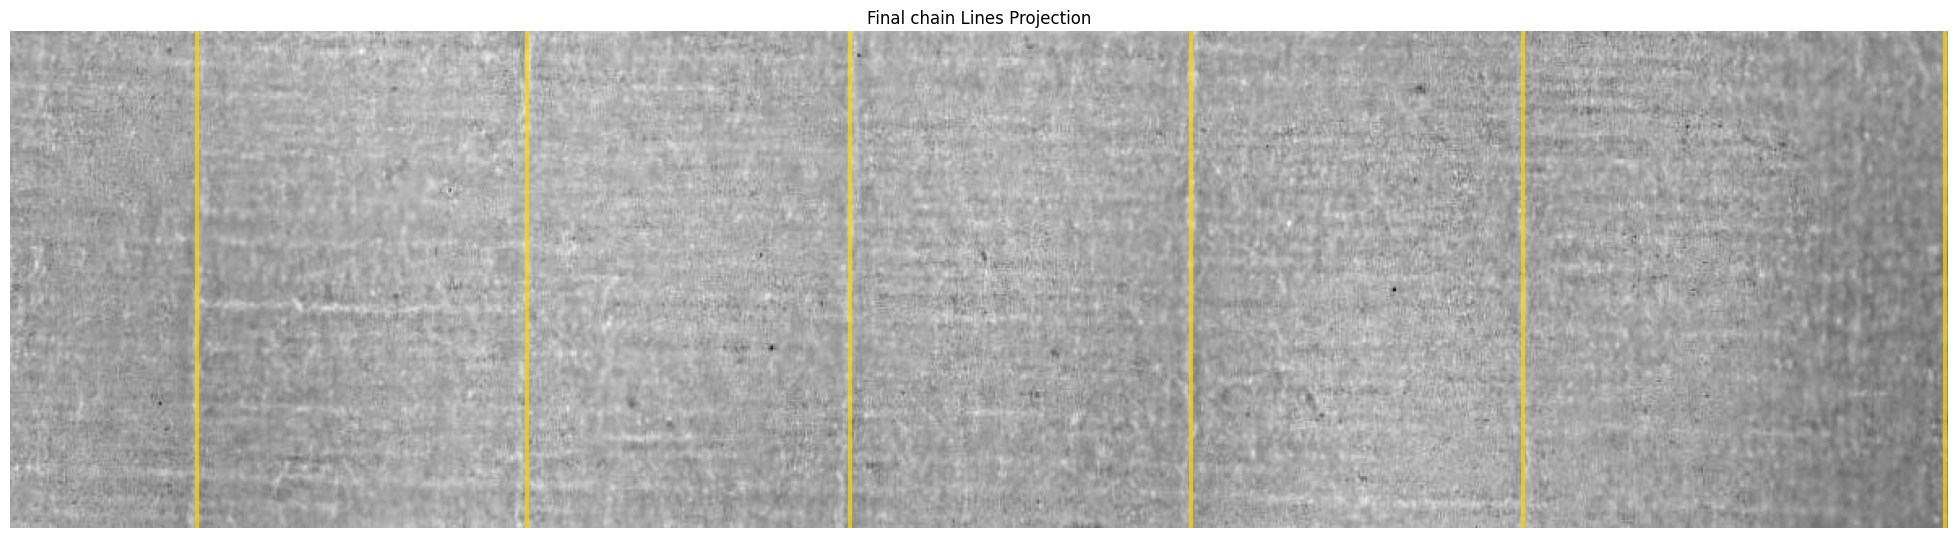

In [ ]:
# Plot over the original image
plt.figure(figsize=(25, 7))


plt.imshow(img_ready, cmap='gray') 

# Draw the detected lines
for peak_x in peaks_y:
    plt.axvline(x=peak_x, color='gold', linewidth=3, linestyle='-', alpha=0.7)

plt.axis('off')
plt.title('Final chain Lines Projection')
plt.show()